In [2]:
# from gabor import generate_gabor

import numpy as np
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

from insilico_stimuli.stimuli import GaborSet

mpl.style.use("seaborn")

In [3]:
gamma = 1
image_size = (100, 100)

In [18]:
def generate_gabor(theta, sigma, Lambda, psi, gamma, center, image_size):
    """
    Gabor generator function.
    Params:
        theta (float): Orientation of the sinusoid (in radians).
        sigma (float): std deviation of the Gaussian.
        Lambda (float): Sinusoid wavelengh (1/frequency).
        psi (float): Phase of the sinusoid.
        gamma (float): The ratio between sigma in x-dim over sigma in y-dim (acts
            like an aspect ratio of the Gaussian).
        center (tuple of integers): The position of the filter.
        image_size (tuple of integers): Image height and width.
    Returns:
        2D torch.tensor: A gabor filter.
    """
    sigma_x = sigma
    sigma_y = sigma / gamma

    ymax, xmax = image_size
    xmax, ymax = (xmax - 1)/2, (ymax - 1)/2
    xmin = -xmax
    ymin = -ymax
    (y, x) = torch.meshgrid(torch.arange(ymin, ymax+1), torch.arange(xmin, xmax+1))

    # Rotation
    x_theta = (x - center[0]) * np.cos(theta) + (y - center[1]) * np.sin(theta)
    y_theta = -(x - center[0]) * np.sin(theta) + (y - center[1]) * np.cos(theta)

    gb = np.exp(-.5 * (x_theta ** 2 / sigma_x ** 2 + y_theta ** 2 / sigma_y ** 2)) * np.cos(2 * torch.pi / Lambda * x_theta + psi)

    return gb


torch.Size([100, 100])


(-0.5, 99.5, 99.5, -0.5)

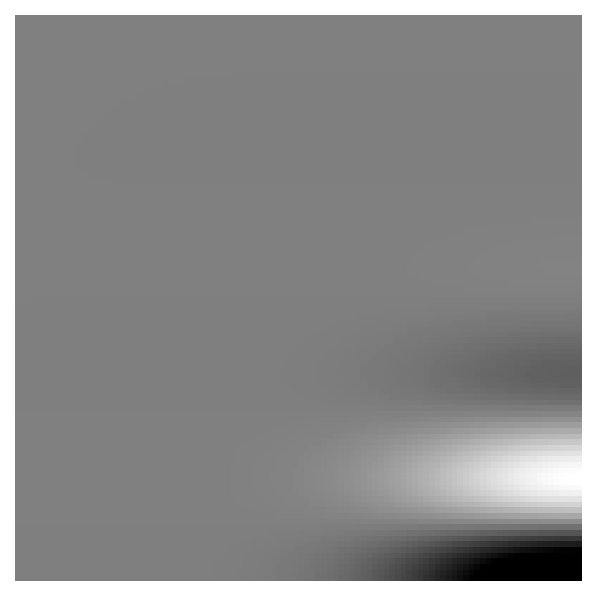

In [19]:
fig, ax = plt.subplots(figsize=(5, 5), dpi=150)
theta = np.pi/2
Lambda = 40
sigma = 20
psi = np.pi
center = (50, 50)

gb = generate_gabor(theta, sigma, Lambda, psi, gamma, center, image_size)
print(gb.shape)
ax.imshow(gb, vmin=-gb.max(), vmax=gb.max(), cmap="gray")
ax.axis("off")

## Generate gabors around half circle with alternating phase


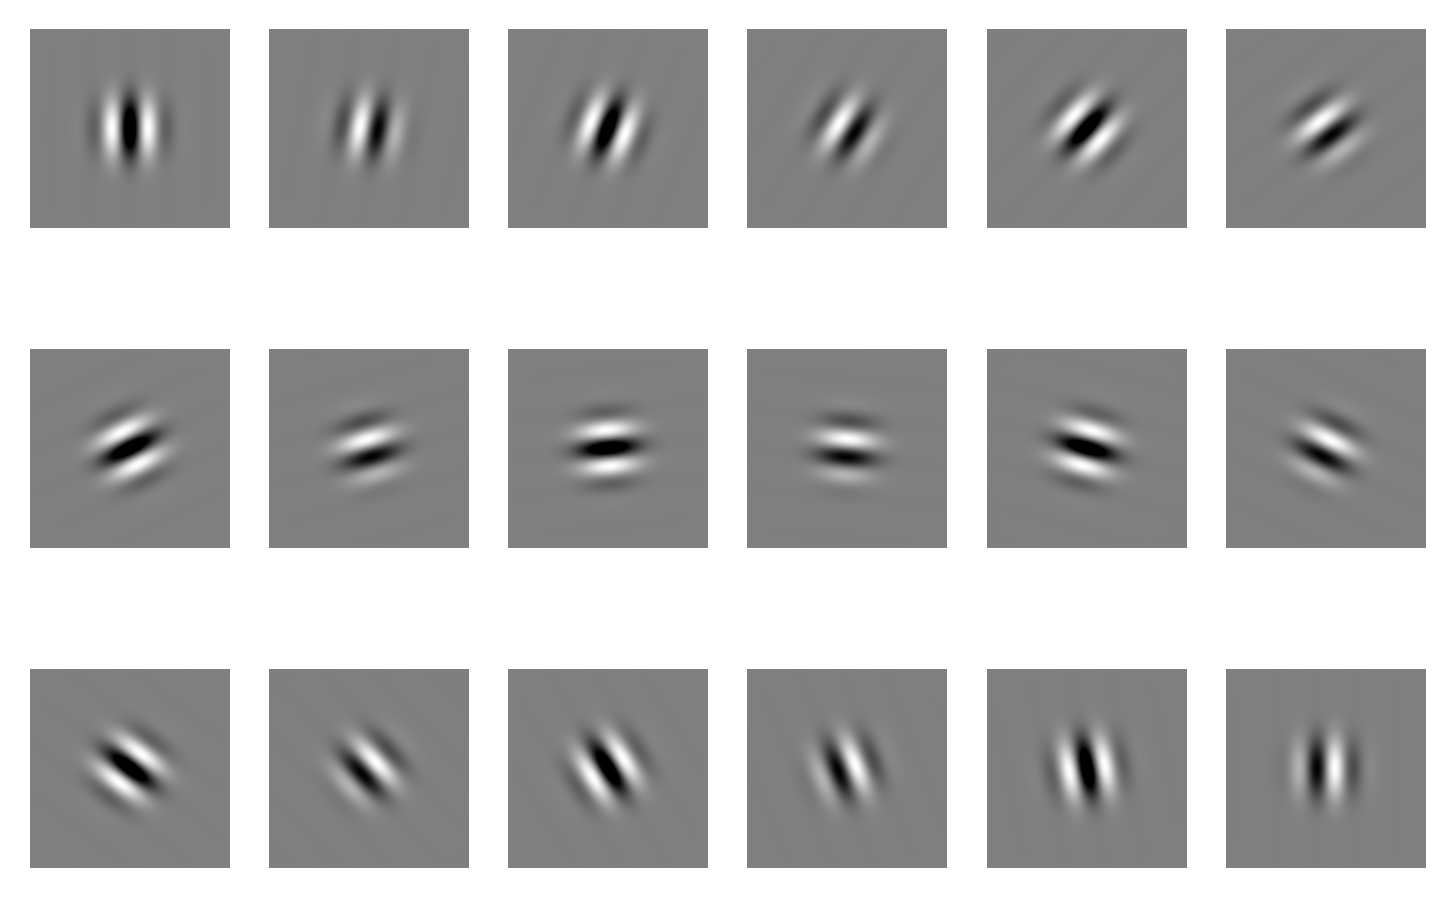

In [6]:
fig, axs = plt.subplots(nrows=3, ncols=6, dpi=300)
Lambda = 40
sigma = 20
psi = np.pi
center = (0, 0)
thetas = torch.linspace(0, torch.pi, 18)
gabors = []
for idx, (theta, ax) in enumerate(zip(thetas, axs.ravel())):
    psi = np.pi / ((idx % 2) + 1)
    gb = generate_gabor(theta, sigma, Lambda, psi, gamma, center, image_size)
    gabors.append(gb)
    ax.imshow(gb, vmin=-gb.max(), vmax=gb.max(), cmap="gray")
    ax.axis("off")

## Generate horizontal gabors

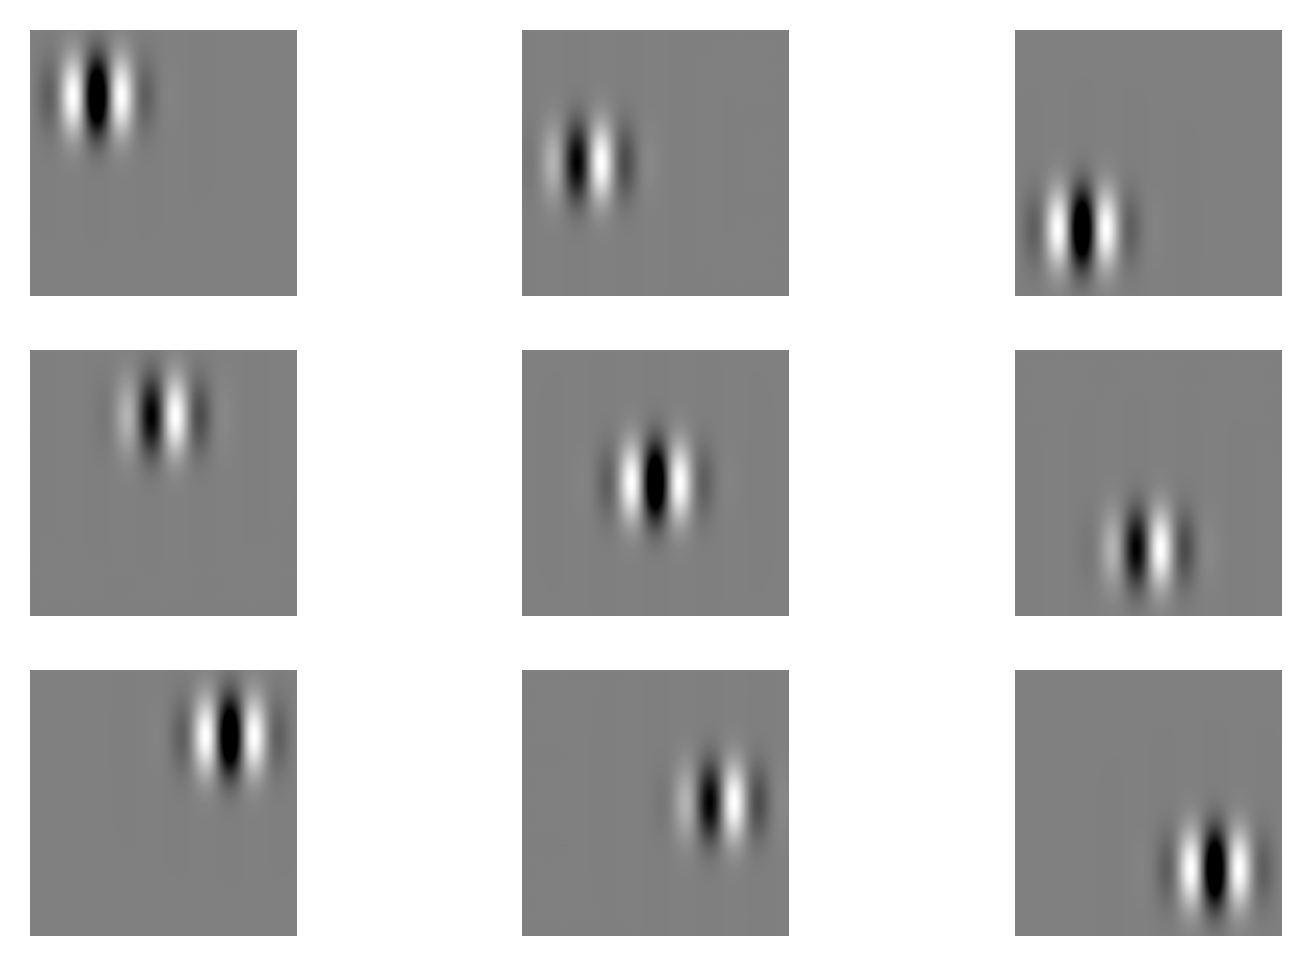

In [14]:
fig, axs = plt.subplots(nrows=3, ncols=3, dpi=300)
Lambda = 40
sigma = 20
psi = np.pi
theta = np.pi
center_coords = list(itertools.product((-50, 0, 50), repeat=2))
gabors = []
for idx, ax in enumerate(axs.ravel()):
    psi = np.pi / ((idx % 2) + 1)
    gb = generate_gabor(theta, sigma, Lambda, psi, gamma, center_coords[idx], image_size)
    # gb2 = generate_gabor(theta * 2, sigma, Lambda, psi, gamma, center_coords[idx], image_size)
    gabors.append(gb)
    ax.imshow(gb, vmin=-gb.max(), vmax=gb.max(), cmap="gray")
    ax.axis("off")

In [16]:
gabors[0].shape

torch.Size([201, 201])

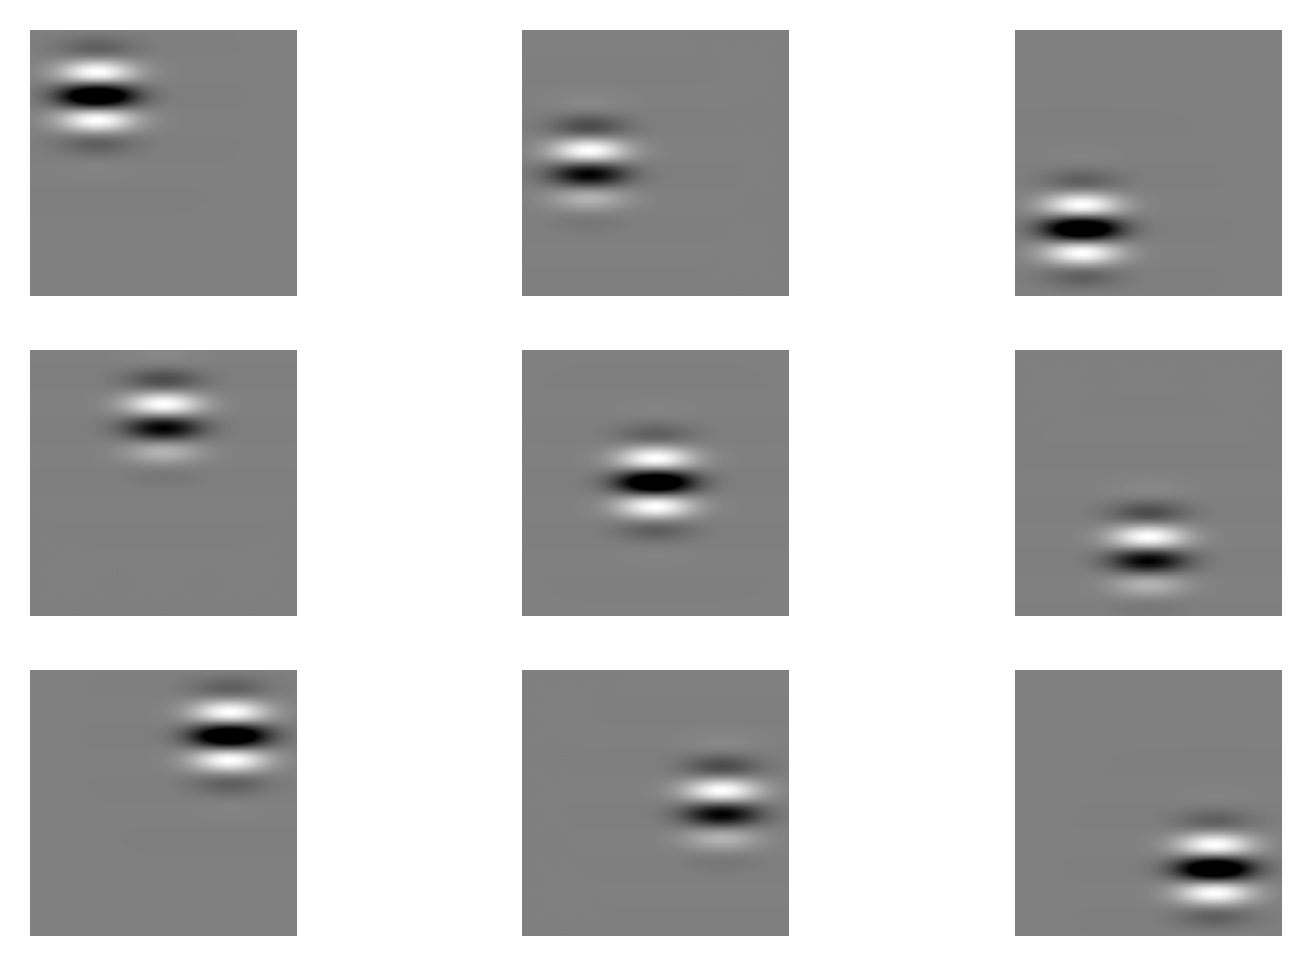

In [9]:
fig, axs = plt.subplots(nrows=3, ncols=3, dpi=300)
Lambda = 40
sigma = 20
psi = np.pi
theta = np.pi/2
center_coords = list(itertools.product((-50, 0, 50), repeat=2))
# gabors = []
for idx, ax in enumerate(axs.ravel()):
    psi = np.pi / ((idx % 2) + 1)
    gb = generate_gabor(theta, sigma, Lambda, psi, gamma, center_coords[idx], image_size)
    # gb2 = generate_gabor(theta * 2, sigma, Lambda, psi, gamma, center_coords[idx], image_size)
    gabors.append(gb)
    ax.imshow(gb, vmin=-gb.max(), vmax=gb.max(), cmap="gray")
    ax.axis("off")

In [13]:
torch.stack(gabors).shape

torch.Size([18, 201, 201])

In [ ]:
from insili